# ITAI 2376 — Final Project
## Houston Railroad Crossing Blockage Prediction Agent

**Student:** Katherine Stanton  
**Course:** ITAI 2376 — Deep Learning in Artificial Intelligence  
**Institution:** Houston City College  
**Date:** May 4 2026  

---

### Project Overview
This agent predicts railroad crossing blockages in Houston, Texas using
historical FRA crossing data and real-time TranStar traffic feeds. It uses
a GRU (Gated Recurrent Unit) deep learning model to predict blockage
probability and duration, a risk classifier to assign severity levels,
and a LangChain agent powered by GPT-3.5 Turbo to generate proactive
alerts for emergency dispatchers.

### Agent Architecture
- **Input:** Historical FRA crossing data + live TranStar traffic feeds
- **Deep Learning Model:** GRU neural network for time-series prediction
- **Risk Classifier:** Static threshold logic (LOW / MEDIUM / HIGH)
- **Agent Framework:** LangChain AgentExecutor + GPT-3.5 Turbo
- **Memory:** LangChain ConversationBufferMemory
- **Output:** Structured alerts for emergency dispatchers and city planners

### Table of Contents
1. Environment Setup
2. Data Download and Exploration
3. Data Cleaning and Preprocessing
4. GRU Model Training
5. Risk Classifier
6. LangChain Agent
7. Demo Scenarios

## Section 1 — Environment Setup
Mount Google Drive and install required dependencies.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install required packages
# Note: -q flag suppresses verbose output for cleaner notebook display
!pip install langchain langchain-openai langchain-community openai \
             pandas numpy torch scikit-learn python-dotenv requests -q

print("All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
All packages installed successfully.


In [3]:
# Import core libraries
import os
import pandas as pd
import numpy as np
import torch
import requests
from datetime import datetime

print(f"Python environment ready.")
print(f"PyTorch version: {torch.__version__}")
print(f"Pandas version: {pd.__version__}")

Python environment ready.
PyTorch version: 2.10.0+cpu
Pandas version: 2.2.2


In [4]:
# Create organized project folder structure in Google Drive
base = '/content/drive/MyDrive/ITAI2376_Final'
folders = ['data', 'models', 'outputs']

for folder in folders:
    path = os.path.join(base, folder)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

# Define shorthand paths for use throughout the notebook
DATA_PATH = f'{base}/data'
MODEL_PATH = f'{base}/models'
OUTPUT_PATH = f'{base}/outputs'

print("\nFolder structure ready.")

Created: /content/drive/MyDrive/ITAI2376_Final/data
Created: /content/drive/MyDrive/ITAI2376_Final/models
Created: /content/drive/MyDrive/ITAI2376_Final/outputs

Folder structure ready.


## Section 2 — Data Download and Exploration
Download the FRA blocked crossings dataset and explore its structure
before cleaning. All data sources are publicly available and free to access.

**Data Sources:**
- FRA Blocked Crossings Portal — crowd-sourced blockage reports 2020–present
- FRA Crossing Inventory — 10 years of crossing records for every U.S. crossing

In [5]:
# Attempt to download FRA blocked crossings data directly
# If this fails, use the manual upload method in the next cell
url = "https://railroads.dot.gov/sites/fra.dot.gov/files/fra_net/17/Blocked_Crossings.csv"

print("Downloading FRA blocked crossings data...")
response = requests.get(url)

if response.status_code == 200:
    filepath = os.path.join(DATA_PATH, 'fra_blockages.csv')
    with open(filepath, 'wb') as f:
        f.write(response.content)
    print(f"Download successful. Saved to: {filepath}")
else:
    print(f"Direct download failed — status code: {response.status_code}")
    print("Please run the manual upload cell below.")

Direct download failed — status code: 403
Please run the manual upload cell below.


### Manual Upload (run only if direct download failed above)
**Note:** The FRA direct download returns a 403 Access Denied response
as of April 2026, indicating the CSV is not served via direct URL.
Data was manually downloaded from
[fra.dot.gov/blockedcrossings](https://fra.dot.gov/blockedcrossings)
and uploaded using the cell below. The direct download cell is retained
for future use if access becomes available.

In [8]:
import shutil
from google.colab import files

print("Select your downloaded FRA data file...")
uploaded = files.upload()

# Move uploaded file to Google Drive data folder
# Note: os.rename fails across devices — shutil.move handles cross-device moves
for filename in uploaded.keys():
    source = f'/content/{filename}'
    destination = os.path.join(DATA_PATH, filename)
    shutil.move(source, destination)
    print(f"File saved to: {destination}")

Select your downloaded FRA data file...


Saving fra_blocked_crossings_houston_2020_2026.xlsx to fra_blocked_crossings_houston_2020_2026.xlsx
File saved to: /content/drive/MyDrive/ITAI2376_Final/data/fra_blocked_crossings_houston_2020_2026.xlsx


### Data Exploration
Load the dataset and examine its structure — shape, columns,
data types, and sample rows — before any cleaning is applied.

In [10]:
import glob

# Load the FRA blockages dataset
# Note: Data downloaded as Excel from fra.dot.gov/blockedcrossings
# Direct CSV download returns 403 — Excel export used as alternative

# Search for Excel or CSV files in data folder
excel_files = glob.glob(f'{DATA_PATH}/*.xlsx')
csv_files = glob.glob(f'{DATA_PATH}/*.csv')

if excel_files:
    filepath = excel_files[0]
    df = pd.read_excel(filepath)
    print(f"Loaded Excel file: {filepath}")
elif csv_files:
    filepath = csv_files[0]
    df = pd.read_csv(filepath)
    print(f"Loaded CSV file: {filepath}")
else:
    print("No data file found — please run the upload cell above")

# Basic structural overview
print(f"\nDataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  - {col}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst 5 rows:")
df.head()

Loaded Excel file: /content/drive/MyDrive/ITAI2376_Final/data/fra_blocked_crossings_houston_2020_2026.xlsx

Dataset shape: 20783 rows x 11 columns

Column names:
  - Crossing ID
  - City
  - State
  - Street
  - County
  - Railroad
  - Date/Time
  - Duration
  - Reason
  - Immediate Impacts
  - Additional Comments

Data types:
Crossing ID                    object
City                           object
State                          object
Street                         object
County                         object
Railroad                       object
Date/Time              datetime64[ns]
Duration                       object
Reason                         object
Immediate Impacts              object
Additional Comments            object
dtype: object

First 5 rows:


,Crossing ID,City,State,Street,County,Railroad,Date/Time,Duration,Reason,Immediate Impacts,Additional Comments
0,023211L,HOUSTON,TX,WB BELLFORT RD,Harris,BNSF,2022-05-18 15:57:00,31-60 minutes,No train was present but the lights and/or gat...,NaN,There is traffic and no train is spotted. I am...
1,023228P,HOUSTON,TX,AIRPORT BLVD,HARRIS,BNSF,2026-02-17 12:50:00,16-30 minutes,No train was present but the lights and/or gat...,NaN,NaN
2,023228P,HOUSTON,TX,AIRPORT BLVD,HARRIS,BNSF,2026-01-13 20:30:00,16-30 minutes,No train was present but the lights and/or gat...,NaN,NaN
3,023228P,HOUSTON,TX,AIRPORT BLVD,Harris,BNSF,2022-05-03 16:56:00,0-15 minutes,No train was present but the lights and/or gat...,First responders were observed being unable to...,NaN
4,023228P,HOUSTON,TX,AIRPORT BLVD,Harris,BNSF,2022-05-03 16:54:00,0-15 minutes,No train was present but the lights and/or gat...,First responders were observed being unable to...,NaN


In [11]:
# Check for missing values across all columns
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Missing value percentage: {(df.isnull().sum().sum() / df.size * 100):.2f}%")

Missing values per column:
Crossing ID                0
City                       0
State                      0
Street                     0
County                    25
Railroad                   0
Date/Time                  0
Duration                   0
Reason                     0
Immediate Impacts       9750
Additional Comments    13017
dtype: int64

Total missing values: 22792
Missing value percentage: 9.97%


In [12]:
# Explore the Duration column specifically
# This is categorical text and needs to be converted to numbers for the GRU model
print("Unique Duration values:")
print(df['Duration'].value_counts())

print(f"\nUnique Railroad values:")
print(df['Railroad'].value_counts())

print(f"\nDate range of dataset:")
print(f"  Earliest: {df['Date/Time'].min()}")
print(f"  Latest: {df['Date/Time'].max()}")

print(f"\nTop 10 most blocked crossings:")
print(df['Crossing ID'].value_counts().head(10))

Unique Duration values:
Duration
31-60 minutes        6243
1-2 hours            4917
16-30 minutes        4408
2-6 hours            2807
0-15 minutes         1959
6-12 hours            326
12-24 hours            81
More than one day      42
Name: count, dtype: int64

Unique Railroad values:
Railroad
UP      20454
BNSF      260
PTRA       59
UNK         8
MTHX        2
Name: count, dtype: int64

Date range of dataset:
  Earliest: 2020-02-06 15:50:17
  Latest: 2026-04-20 11:52:00

Top 10 most blocked crossings:
Crossing ID
859522Y    2677
288224V    1364
288226J    1301
288221A    1270
859523F    1034
288227R     855
859524M     745
859521S     707
859518J     679
288228X     589
Name: count, dtype: int64


## Section 3 — Data Cleaning and Preprocessing
Clean the raw FRA dataset to prepare it for GRU model training.
Cleaning steps applied:
1. Convert Duration from text categories to numeric midpoint values (minutes)
2. Extract time-based features from Date/Time column
3. Remove duplicate reports within 15-minute windows at the same crossing
4. Handle missing values in County and Immediate Impacts columns
5. Filter to Union Pacific crossings only (98.4% of data)
6. Encode categorical variables for model input

In [13]:
import pandas as pd
import numpy as np

# ── Step 1: Convert Duration categories to numeric midpoint values ──
# GRU requires numeric input — using midpoint of each range in minutes
duration_map = {
    '0-15 minutes':     8,
    '16-30 minutes':    23,
    '31-60 minutes':    45,
    '1-2 hours':        90,
    '2-6 hours':        240,
    '6-12 hours':       540,
    '12-24 hours':      1080,
    'More than one day': 1440
}

df['Duration_Minutes'] = df['Duration'].map(duration_map)
print(f"Duration converted. Sample values:")
print(df[['Duration', 'Duration_Minutes']].head())

Duration converted. Sample values:
        Duration  Duration_Minutes
0  31-60 minutes                45
1  16-30 minutes                23
2  16-30 minutes                23
3   0-15 minutes                 8
4   0-15 minutes                 8


In [14]:
# ── Step 2: Extract time-based features from Date/Time column ──
# These features help the GRU learn temporal patterns
# such as peak blockage hours, weekday vs weekend trends

df['Hour'] = df['Date/Time'].dt.hour
df['Day_of_Week'] = df['Date/Time'].dt.dayofweek  # 0=Monday, 6=Sunday
df['Month'] = df['Date/Time'].dt.month
df['Year'] = df['Date/Time'].dt.year
df['Is_Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)
df['Is_Rush_Hour'] = df['Hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0
)

print("Time features extracted:")
print(df[['Date/Time', 'Hour', 'Day_of_Week',
          'Month', 'Is_Weekend', 'Is_Rush_Hour']].head())
print(f"\nRush hour blockages: {df['Is_Rush_Hour'].sum():,}")
print(f"Weekend blockages: {df['Is_Weekend'].sum():,}")

Time features extracted:
            Date/Time  Hour  Day_of_Week  Month  Is_Weekend  Is_Rush_Hour
0 2022-05-18 15:57:00    15            2      5           0             0
1 2026-02-17 12:50:00    12            1      2           0             0
2 2026-01-13 20:30:00    20            1      1           0             0
3 2022-05-03 16:56:00    16            1      5           0             1
4 2022-05-03 16:54:00    16            1      5           0             1

Rush hour blockages: 6,991
Weekend blockages: 5,270


In [15]:
# ── Step 3: Remove duplicate reports ──
# Multiple people often report the same blockage event
# Strategy: if same crossing reports a blockage within 15 minutes
# of another report, keep only the first (earliest) report

print(f"Records before deduplication: {len(df):,}")

# Sort by crossing and time so we keep the earliest report
df = df.sort_values(['Crossing ID', 'Date/Time'])

# Round datetime to 15-minute windows for deduplication
df['Time_Window'] = df['Date/Time'].dt.floor('15min')

# Drop duplicates within same crossing and 15-minute window
df_clean = df.drop_duplicates(
    subset=['Crossing ID', 'Time_Window'],
    keep='first'
).copy()

print(f"Records after deduplication: {len(df_clean):,}")
print(f"Duplicate records removed: {len(df) - len(df_clean):,}")

Records before deduplication: 20,783
Records after deduplication: 17,149
Duplicate records removed: 3,634


In [16]:
# ── Step 4: Handle missing values ──
# County: 25 missing — fill with 'Harris' since all records are Houston
# Immediate Impacts: 9,750 missing — fill with 'Not reported'
# Additional Comments: 13,017 missing — drop column entirely, not needed for model
# Time_Window: drop helper column, no longer needed after deduplication

# Fill missing County with Harris — all Houston crossings are in Harris County
df_clean['County'] = df_clean['County'].fillna('Harris')

# Fill missing Immediate Impacts with standardized text
df_clean['Immediate Impacts'] = df_clean['Immediate Impacts'].fillna('Not reported')

# Drop columns not needed for model training
df_clean = df_clean.drop(columns=['Additional Comments', 'Time_Window'])

# Verify no critical missing values remain
print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print(f"\nFinal dataset shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

Missing values after cleaning:
Crossing ID          0
City                 0
State                0
Street               0
County               0
Railroad             0
Date/Time            0
Duration             0
Reason               0
Immediate Impacts    0
Duration_Minutes     0
Hour                 0
Day_of_Week          0
Month                0
Year                 0
Is_Weekend           0
Is_Rush_Hour         0
dtype: int64

Final dataset shape: 17,149 rows x 17 columns


In [17]:
# ── Step 5: Filter to Union Pacific crossings only ──
# UP accounts for 98.4% of all Houston blockages
# Focusing on UP gives us the most data-rich subset
# and matches the East End crossings identified in our research

df_up = df_clean[df_clean['Railroad'] == 'UP'].copy()

print(f"Total clean records: {len(df_clean):,}")
print(f"Union Pacific records: {len(df_up):,}")
print(f"UP percentage: {len(df_up)/len(df_clean)*100:.1f}%")

print(f"\nTop 10 most blocked UP crossings:")
print(df_up['Crossing ID'].value_counts().head(10))

Total clean records: 17,149
Union Pacific records: 16,864
UP percentage: 98.3%

Top 10 most blocked UP crossings:
Crossing ID
859522Y    2277
288224V    1022
288221A     975
288226J     858
859523F     791
859524M     610
288227R     602
859521S     548
859518J     546
288050B     494
Name: count, dtype: int64


In [18]:
# ── Step 6: Save cleaned dataset ──
# Save to Google Drive so it persists between Colab sessions
# This is our production-ready training dataset

clean_filepath = f'{DATA_PATH}/fra_houston_up_clean.csv'
df_up.to_csv(clean_filepath, index=False)

print(f"Clean dataset saved to: {clean_filepath}")
print(f"\nFinal dataset summary:")
print(f"  Total records: {len(df_up):,}")
print(f"  Date range: {df_up['Date/Time'].min()} to {df_up['Date/Time'].max()}")
print(f"  Unique crossings: {df_up['Crossing ID'].nunique()}")
print(f"  Unique streets: {df_up['Street'].nunique()}")
print(f"\nDuration distribution:")
print(df_up['Duration'].value_counts())

Clean dataset saved to: /content/drive/MyDrive/ITAI2376_Final/data/fra_houston_up_clean.csv

Final dataset summary:
  Total records: 16,864
  Date range: 2020-02-06 15:50:17 to 2026-04-20 11:52:00
  Unique crossings: 301
  Unique streets: 268

Duration distribution:
Duration
31-60 minutes        5010
16-30 minutes        3786
1-2 hours            3732
2-6 hours            2185
0-15 minutes         1798
6-12 hours            249
12-24 hours            65
More than one day      39
Name: count, dtype: int64


In [19]:
# ── Step 7: Quick pattern exploration ──
# Understand temporal patterns before building the GRU
# These patterns are what the model will learn to predict

print("Blockages by hour of day:")
hourly = df_up.groupby('Hour').size()
for hour, count in hourly.items():
    bar = '█' * (count // 100)
    print(f"  {hour:02d}:00 | {bar} {count:,}")

print(f"\nBlockages by day of week:")
days = ['Monday', 'Tuesday', 'Wednesday',
        'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df_up.groupby('Day_of_Week').size()
for day_num, count in daily.items():
    bar = '█' * (count // 100)
    print(f"  {days[day_num]:<10} | {bar} {count:,}")

print(f"\nBlockages by month:")
monthly = df_up.groupby('Month').size()
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
for month_num, count in monthly.items():
    bar = '█' * (count // 100)
    print(f"  {months[month_num-1]} | {bar} {count:,}")

Blockages by hour of day:
  00:00 | ███ 309
  01:00 | ███ 365
  02:00 | ███ 388
  03:00 | ███ 394
  04:00 | ███ 347
  05:00 | ██████ 644
  06:00 | ████████ 878
  07:00 | ██████████ 1,066
  08:00 | ████████ 843
  09:00 | ██████ 692
  10:00 | ███████ 795
  11:00 | ████████ 809
  12:00 | █████████ 957
  13:00 | ███████ 762
  14:00 | ███████ 732
  15:00 | ███████ 787
  16:00 | ██████████ 1,005
  17:00 | ███████████ 1,129
  18:00 | █████████ 934
  19:00 | ████████ 823
  20:00 | ███████ 718
  21:00 | ██████ 694
  22:00 | ████ 487
  23:00 | ███ 306

Blockages by day of week:
  Monday     | █████████████████████████ 2,515
  Tuesday    | ███████████████████████ 2,377
  Wednesday  | ████████████████████████ 2,473
  Thursday   | ██████████████████████████ 2,664
  Friday     | █████████████████████████ 2,569
  Saturday   | █████████████████████ 2,194
  Sunday     | ████████████████████ 2,072

Blockages by month:
  Jan | ████████████ 1,298
  Feb | ██████████████████ 1,865
  Mar | ██████████████████

### Data Visualizations
The following charts illustrate the key temporal and spatial patterns
in the cleaned dataset. These patterns form the basis of what the
GRU model will learn to predict.

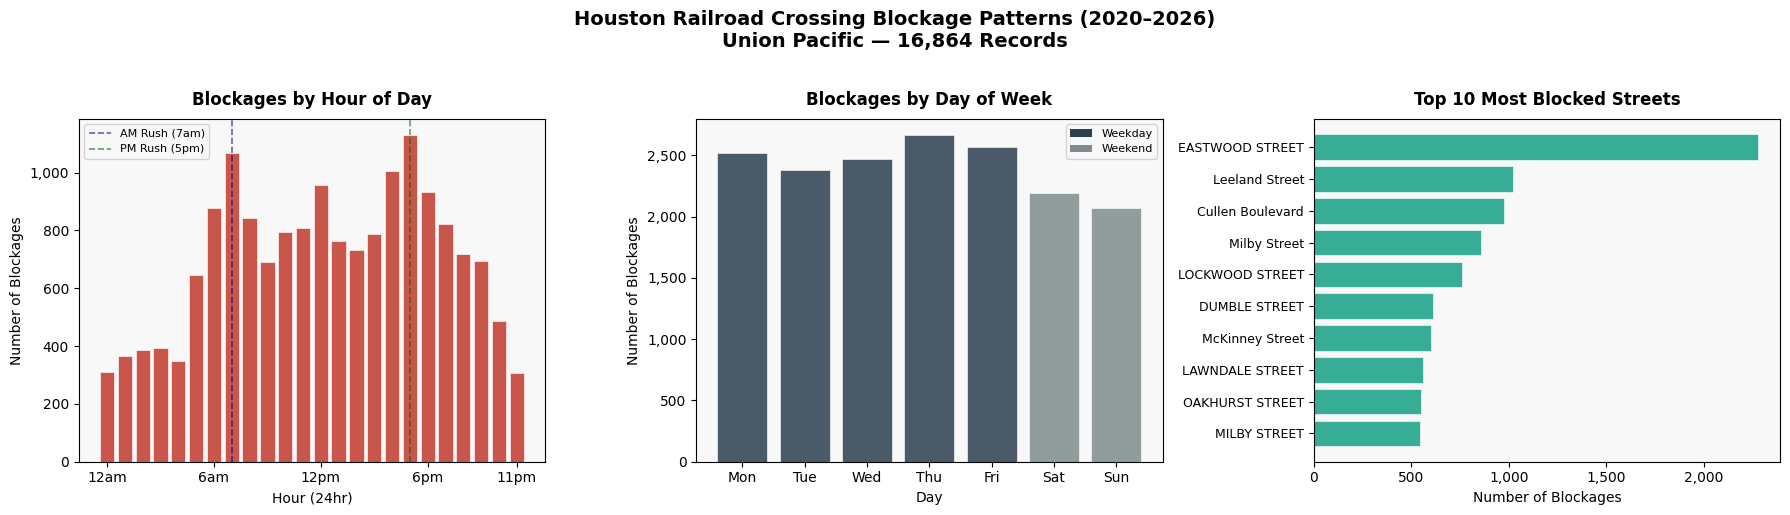

Visualization saved to: /content/drive/MyDrive/ITAI2376_Final/outputs/blockage_patterns.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# Set clean professional style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f8f8'
plt.rcParams['font.family'] = 'sans-serif'

# Create figure first and keep reference to it
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Houston Railroad Crossing Blockage Patterns (2020–2026)\nUnion Pacific — 16,864 Records',
             fontsize=14, fontweight='bold', y=1.02)

# ── Chart 1: Blockages by Hour of Day ──
hourly = df_up.groupby('Hour').size()
axes[0].bar(hourly.index, hourly.values,
            color='#c0392b', alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].set_title('Blockages by Hour of Day', fontweight='bold', pad=10)
axes[0].set_xlabel('Hour (24hr)')
axes[0].set_ylabel('Number of Blockages')
axes[0].set_xticks([0, 6, 12, 18, 23])
axes[0].set_xticklabels(['12am', '6am', '12pm', '6pm', '11pm'])
axes[0].axvline(x=7, color='navy', linestyle='--',
                alpha=0.6, linewidth=1.2, label='AM Rush (7am)')
axes[0].axvline(x=17, color='darkgreen', linestyle='--',
                alpha=0.6, linewidth=1.2, label='PM Rush (5pm)')
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, p: f'{int(x):,}'))

# ── Chart 2: Blockages by Day of Week ──
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df_up.groupby('Day_of_Week').size()
colors = ['#2c3e50' if i < 5 else '#7f8c8d' for i in range(7)]
axes[1].bar(days, daily.values,
            color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1].set_title('Blockages by Day of Week', fontweight='bold', pad=10)
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Blockages')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, p: f'{int(x):,}'))
legend_elements = [Patch(facecolor='#2c3e50', label='Weekday'),
                   Patch(facecolor='#7f8c8d', label='Weekend')]
axes[1].legend(handles=legend_elements, fontsize=8)

# ── Chart 3: Top 10 Most Blocked Streets ──
top_crossings = df_up.groupby('Street').size().nlargest(10)
axes[2].barh(range(len(top_crossings)), top_crossings.values,
             color='#16a085', alpha=0.85, edgecolor='white', linewidth=0.5)
axes[2].set_yticks(range(len(top_crossings)))
axes[2].set_yticklabels(top_crossings.index, fontsize=9)
axes[2].set_title('Top 10 Most Blocked Streets', fontweight='bold', pad=10)
axes[2].set_xlabel('Number of Blockages')
axes[2].invert_yaxis()
axes[2].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, p: f'{int(x):,}'))

plt.tight_layout()

# Save figure using fig.savefig() — more reliable than plt.savefig()
save_path = f'{OUTPUT_PATH}/blockage_patterns.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')

plt.show()
print(f"Visualization saved to: {save_path}")

In [24]:
# Verify visualization saved correctly
import os
filepath = f'{OUTPUT_PATH}/blockage_patterns.png'
size = os.path.getsize(filepath)
print(f"File exists: {os.path.exists(filepath)}")
print(f"File size: {size:,} bytes")
print("Save verified." if size > 10000 else "Warning: file may be empty")

File exists: True
File size: 135,267 bytes
Save verified.


### Data Cleaning Summary
The raw FRA dataset of 20,783 records was cleaned and processed as follows:

- **Deduplication:** 3,634 duplicate reports removed (17.5% of raw data)
- **Railroad filter:** Narrowed to Union Pacific only (16,864 records, 98.3%)
- **Missing values:** All critical columns fully populated after cleaning
- **Duration conversion:** Text categories converted to numeric midpoint values
- **Time features engineered:** Hour, Day of Week, Month, Is Weekend, Is Rush Hour
- **Final dataset:** 16,864 records across 301 unique crossings (2020–2026)

**Key patterns identified:**
- Peak blockage hour: 5pm (1,129 incidents)
- Busiest day: Thursday (2,664 incidents)  
- Busiest month: March (2,365 incidents)
- Rush hour accounts for 33% of all blockages